In [1]:
from collections import defaultdict
import json
from torch.utils.data import Dataset, DataLoader
import os, sys, torch, random
from pathlib import Path
import numpy as np
from torchvision import tv_tensors                                      
from utils.utils import (
    crop_ultrasound_pil,
    extract_bbox_ultrasound_cv2,
    organ_to_class_dict,
    dataset_to_organ_dict,
    dataset_for_classification,
    dataset_for_segmentation,
    multi_cls_labels_dict,
    resize_pad,
)
from PIL import Image
from torchvision.transforms.v2.functional import pil_to_tensor, center_crop
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image
from tqdm import tqdm 
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import numpy as np
from data_classes.datasets import USdatasetOmni

/home/nicola/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-04 10:51:46.407798: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 10:51:46.440948: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 10:51:47.169134: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different nume

In [2]:
from utils.utils import get_sft_transforms
from utils.paths import *


dataset = USdatasetOmni(
    base_dir=DATA_DIR,
    split="val_cls",
    transforms=get_sft_transforms(train=False),
    out_size=512,
    data_type="segmentation",
    ccl_crop=False,
    keep_aspect_ratio=True,
    self_norm=True, 
    skip_dataset="Testicle",
    id_dropout=0.0
)
len(dataset)

1163

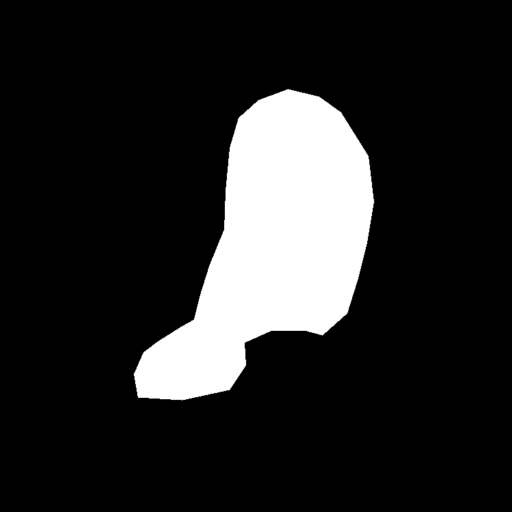

In [16]:
from nets.unet_attn import canonicalize_mask_batch_normalized, canonicalize_mask_batch
from torchvision.transforms.functional import to_pil_image
mask = dataset.__getitem__(10)['masks']
to_pil_image(mask)

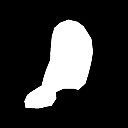

In [ ]:

to_pil_image(canonicalize_mask_batch_normalized(mask.unsqueeze(0), canon_res=128))

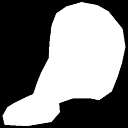

In [15]:
to_pil_image(canonicalize_mask_batch(mask.unsqueeze(0), canon_res=128))


In [3]:
from argparse import Namespace
from collections import defaultdict
from copy import deepcopy
from transformers.trainer import Trainer
from transformers.training_args import TrainingArguments
from data_classes.datasets import USdatasetOmni
from torchvision.transforms import InterpolationMode, v2
import torch, wandb, random
from sklearn.metrics import accuracy_score
from nets.cls_net import OmniClsCBAM
from nets.segm_net import UNet2DFiLM, MedSAM, MedSAMPrompt
from utils.paths import DATA_DIR
from utils.utils import organ_to_class_dict, multi_cls_labels_dict, generate_run_hash
import numpy as np
from utils.utils import (
    get_sft_transforms,
    compute_dsc,
    class_to_organ_dict,
    compute_nsd,
    mask_overlap_visualization,
)
from utils.stratified_splits import build_train_val_datasets
from utils.paths import *
from torch.utils.data import Subset, ConcatDataset


In [ ]:
from segment_anything import sam_model_registry
sam_model = sam_model_registry["vit_b"](checkpoint=MEDSAM_BASE_WEIGHTS)
print(sum([p.numel() for p in sam_model.parameters()]))
model = MedSAMPrompt(
            image_encoder=deepcopy(sam_model.image_encoder),
            mask_decoder=deepcopy(sam_model.mask_decoder),
            prompt_encoder=deepcopy(sam_model.prompt_encoder),
            predict_bboxes=True,
            freeze_image_encoder=0,
        )
model.cuda()

In [ ]:
training_args = TrainingArguments(
    output_dir="./loggings/debug",
    # num_train_epochs=args.epochs,
    max_steps=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    logging_dir="./logs",
    seed=42,
    save_strategy="steps",
    eval_strategy="steps",
    save_steps=int(1 / 100),
    eval_steps=int(1 / 100),
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,
    report_to=None,
    dataloader_num_workers=8,
    logging_steps=10,
    log_level="info",
    eval_accumulation_steps=100,
    optim="adamw_torch",
    learning_rate=1e-3,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    gradient_accumulation_steps=2,
    # fp16=True,
    # push_to_hub=False,
)

In [ ]:
from safetensors.torch import load_file
from utils.distill_enc import apply_lora_to_encoder
# peft_model_dict = torch.load("/media/raid0/US_FiLMUNet/loggings/peft_unet4_2/final_model_lora.pth")
model = UNet2DFiLM(
    in_channels=3,
    num_classes=1,
    # n_organs=len(organ_to_class_dict),
    n_organs=8,
    size=32,
    depth=5,
    film_start=0,
    use_film=True,
    distill=True
)
state_dict = load_file("/media/raid0/US_FiLMUNet/checkpoints/unet5/model.safetensors")
model.load_state_dict(state_dict, strict=False)

model.cuda()

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def compute_erf(model, input_size=(1, 3, 512, 512), device='cuda'):
    """
    Compute effective receptive field using gradient method
    """
    model.eval()
    
    # Create input with requires_grad
    x = torch.randn(input_size, requires_grad=True, device=device)
    
    # Forward pass
    # output = model(x)

    output = model.forward(
        pixel_values=x.cuda(),
        # masks=data["masks"].unsqueeze(0).repeat(4,1,1).cuda(),
        organ_id=torch.Tensor([0]).long().cuda(),
    )['logits']
    # Get center position of output
    if len(output.shape) == 4:  # For CNNs: (B, C, H, W)
        center_h, center_w = output.shape[2] // 2, output.shape[3] // 2
        target = output[0, :, center_h, center_w].sum()
    else:  # For fully connected
        target = output[0].sum()
    
    # Backward pass
    target.backward()
    
    # Get gradient magnitude
    erf = x.grad[0].abs().sum(dim=0).cpu().numpy()
    
    return erf

def compute_erf_averaged(model, input_size=(1, 3, 512, 512), 
                         device='cuda', n_samples=100):
    model.eval()
    erf_sum = None
    
    for i in range(n_samples):
        x = torch.randn(input_size, requires_grad=True, device=device)
        output = model.forward(
            pixel_values=x.cuda(),
            # masks=data["masks"].unsqueeze(0).repeat(4,1,1).cuda(),
            organ_id=torch.Tensor([0]).long().cuda(),
        )['logits']
        
        # Center pixel
        if len(output.shape) == 4:
            center_h, center_w = output.shape[2] // 2, output.shape[3] // 2
            target = output[0, :, center_h, center_w].sum()
        else:
            target = output[0].sum()
        
        target.backward()
        
        erf = x.grad[0].abs().sum(dim=0).cpu().numpy()
        
        if erf_sum is None:
            erf_sum = erf
        else:
            erf_sum += erf
    
    return erf_sum / n_samples
# Visualize
erf = compute_erf_averaged(model)
plt.imshow(erf, cmap='hot')
plt.colorbar()
plt.title('Effective Receptive Field')
plt.show()

In [ ]:
from train.segm_train import UNet2DFiLM
model = UNet2DFiLM(
    in_channels=3,
    num_classes=1,
    # n_organs=len(organ_to_class_dict),
    n_organs=8,
    size=32,
    depth=4,
    film_start=0,
    use_film=True,
    distill=False
)
model.cuda()
print(sum([p.numel() for p in model.parameters()]))
from safetensors.torch import load_file

state_dict = load_file("/work/phd_ultrasounds/UUSIC_new/checkpoints/unet4/model.safetensors")
model.load_state_dict(state_dict)

In [ ]:
from nets.unet_attn import UNet2DAttn
from safetensors.torch import load_file
model = UNet2DAttn(
    in_channels=3,
    num_classes=1,
    n_organs=10,
    size=32,
    depth=4,
    attn_start=0,      # Start attention from first level
    use_attn=True,     # Enable attention
    img_size=512,      # Input image size
    patch_size=8,     # 16×16 patches → 256 patches total
    emb_dim=768,       # Embedding dimension
    n_heads=8,          # Number of attention heads,
    # n_transformer_layers = 12,
    distill = 1,
    use_dwt=True,
    wavelet='haar',
    dwt_bands=['HH'],
    use_shape = True,
    shape_res=32

)
model.cuda()
print(sum([p.numel() for n, p in model.named_parameters() if 'distill_model' not in n]))
state_dict = load_file("/media/disk1/US_FiLMUNet/loggings/c86788dac0c1/checkpoint-9600/model.safetensors")
model.load_state_dict(state_dict)

In [ ]:
tmp = torch.sigmoid(model.shared_attn.shape_proj(model.shared_attn.shape_embed.weight.clone().detach()).reshape(11, 32, 32))

In [ ]:
from torchvision.transforms.functional import to_pil_image

to_pil_image((tmp[1]>0.5).to(torch.float32))

In [ ]:
from nets.unet_attn import FiLMLayer
print("--- FiLM/Attention Injection Points ---")
for name, module in model.named_modules():
    if isinstance(module, FiLMLayer):
        # This shows the path to every active modulation point
        print(f"Conditioning injected at: {name}")

In [ ]:
model.cuda()
print(sum([p.numel() for p in model.parameters()]))
from safetensors.torch import load_file

state_dict = load_file("/media/raid0/US_FiLMUNet/loggings/dd162636aa38/checkpoint-8400/model.safetensors")
model.load_state_dict(state_dict, strict = False)

In [ ]:
sd = model.state_dict()
seen = {}
for k, v in sd.items():
    ptr = v.storage().data_ptr() if v.is_cuda is False else v.untyped_storage().data_ptr()
    seen.setdefault(ptr, []).append(k)

shared = {ptr:names for ptr,names in seen.items() if len(names) > 1}
print("num shared storages:", len(shared))
for ptr, names in list(shared.items())[:10]:
    print(names)


In [ ]:
from torch import nn
import torch

updated = 0
with torch.no_grad():
    for name, module in model.named_modules():
        # your FiLM2d has attribute .embed which is nn.Embedding
        # print(name)
        if hasattr(module, "patch_embed"):
            #  and isinstance(getattr(module, "embed"), nn.Embedding)
            # emb: nn.Embedding = module.embed
            # W = emb.weight  # [num_embeddings, emb_dim]
            # if W.shape[0] < 10:
            #     raise ValueError(f"{name}.embed has {W.shape[0]} rows (<10); can't set rows 8 and 9.")
            # mean_0_7 = W[0:8].mean(dim=0)   # [emb_dim]
            # W[8].copy_(mean_0_7)
            # W[9].copy_(mean_0_7)
            updated += 1
print(updated)

In [ ]:
data["masks"].shape

In [ ]:
data = dataset.__getitem__(0)
data.keys()
model.eval()
with torch.no_grad():
    out = model.forward(
        pixel_values=data["pixel_values"].unsqueeze(0).repeat(4,1,1,1).cuda(),
        masks=data["masks"].unsqueeze(0).repeat(4,1,1).cuda(),
        organ_id=torch.Tensor([-1]).long().repeat(4).cuda(),
    )
out['loss']

In [ ]:
out.keys()

In [ ]:
enc = model.encode(data['pixel_values'].unsqueeze(0).cuda(), torch.Tensor([data['organ_id']]).long().cuda())[0]

In [ ]:
from segment_anything import sam_model_registry
from copy import deepcopy
from nets.segm_net import UNet2DFiLM, MedSAM, MedSAMPrompt
from safetensors.torch import load_file
sam_model = sam_model_registry["vit_b"](checkpoint=MEDSAM_BASE_WEIGHTS)

model = MedSAM(
    image_encoder=deepcopy(sam_model.image_encoder),
    mask_decoder=deepcopy(sam_model.mask_decoder),
    prompt_encoder=deepcopy(sam_model.prompt_encoder),
    predict_bboxes=True,
    freeze_image_encoder=0,
)
state_dict = load_file(
    "/work/phd_ultrasounds/UUSIC_new/checkpoints/medsam_unfreezed/model.safetensors"
)
model.load_state_dict(state_dict)
load_result = model.load_state_dict(state_dict)
print(load_result)
model.eval()
model = model.cuda()

In [ ]:
with torch.no_grad():
    image_embedding = model.image_encoder(data['pixel_values'].unsqueeze(0).cuda()) 
    image_embedding

In [ ]:
with torch.no_grad():
    image_pe = model.prompt_encoder.get_dense_pe()
            # Decode mask
    low_res_masks, iou_predictions = model.mask_decoder(
            image_embeddings=image_embedding,  # (B, 256, 64, 64)
            image_pe=image_pe,  # (1, 256, 64, 64)
            sparse_prompt_embeddings=model.learned_sparse_embeddings,  # (B, 2, 256)
            dense_prompt_embeddings=model.learned_dense_embeddings,  # (B, 256, 64, 64)
            multimask_output=False,
        ) 

In [ ]:
wandb.login()
wandb.init(
    entity='nmorelli-unimore',
    project='uusic_segm2',
    name='unet5_onpublic',
    # config=args,
    # resume = True,
    # id = 'wp55lzxe'
)

In [ ]:
tmp.std()

In [ ]:
model.shared_attn.organ_embed.weight[-1].std()

In [ ]:
from torch import  nn

with torch.no_grad():
    nn.init.normal_(
        model.shared_attn.organ_embed.weight,
        mean=0.0,
        std=0.02
    )


In [ ]:
nn.init.normal_(self.organ_embed.weight, mean=0, std=0.02)

In [ ]:
from train.segm_train import compute_metrics, CustomTrainerWithSampler

trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        eval_dataset=dataset,
        compute_metrics=compute_metrics,
        # train_sampler=train_sampler,
    )

In [ ]:
metrics = trainer.evaluate()

In [ ]:
metrics

In [ ]:
predictions = trainer.predict(test_dataset=dataset)

In [ ]:
predictions[2]

In [ ]:
data = dataset.__getitem__(0)
data.keys()
out = model(pixel_values = data['pixel_values'].unsqueeze(0).cuda(), organ_id = data['organ_id'].clone().cuda())

In [ ]:
out

In [ ]:
from torchvision.transforms.v2.functional import to_pil_image

to_pil_image((torch.sigmoid(out['logits']) > 0.7).to(torch.float32))

In [ ]:
wandb.finish()